# Data Workshop 2



**Instructors:** Argen Smith (PO), Sophie Wynn (CS), Tommy Stone (AOS)

## Before the Workshop

### Installations
We expect that you will have Conda and VS Code installed on your computer before attending the workshop. If you need help we will have **office hours** to help with installs and troubleshoot issues from 12:30pm - 1:25pm in Munk Lab 303 on 09/18. 

See the below website for instructions to install
1) [Python Installation with Conda](https://eldavenport.github.io/SIO-PythonEarthScience/)
2) [VSCode Installation](https://eldavenport.github.io/SIO-PythonEarthScience/installation/software_install/vscode_install.html)

### Github Repository

All notebooks can be found on the [Math Workshop Github](https://github.com/tgstone/sio-math-workshop/)


### Data
You can download the available datasets that we will used for the workshop from our [data folder on Google drive](https://drive.google.com/drive/folders/1csB0khdMHT0-xp3sEaG3N3kgKTbG-lbO?usp=drive_link). You will need your UCSD google account to access the site.

In [29]:
# importing libraries for this workshop

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmocean import cm
import scipy

## 1) Interpolation and weighted means over the California Current System

Teacher: Tommy Stone
TA: Sophie Wynn, Argen Smith

Often times we will have datasets with missing or incorrect points. These values can be either filled with 

- large or small numbers that are not possible in our variable range
- Not A Number (NaN) values. 
  
In this section we will explore the global Sea Surface Temperature dataset to interpolate between missing years. After the instruction section we will interpolate over a region to create a smaller grid and compare the temperature values with a reanalysis product. 

## DATASETS REQUIRED

We will be using the below datasets. You can download this notebook and run directly 

- sst_monthly_nans.nc
- sst_monthlymean.nc  
- sst.oisst.mon.ltm.1992-2020.nc


### Let's go ahead and load the sst_monthly_nans.nc file. A couple of review questions

1) What is the period of the data? (from when to when)
2) What are the units of the Sea Surface Temperature (SST)?

In [ ]:
# constants
data_path = "data/sst_monthly_nans.nc"
xr_sst = xr.open_dataset(data_path)
xr_sst

<xarray.Dataset> Size: 36MB
Dimensions:  (lat: 89, lon: 180, time: 559)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2026-07-01
Data variables:
    sst      (time, lat, lon) float32 36MB ...

### Slicing the data

The goal of this section is that we want to compare the 20-year average over two periods near the CCS. The periods are 

- Period 1: 1985 - 2004
- Period 2: 2005 - 2024


In [ ]:
# California Current System bounding box (0-360 longitude convention)
# Latitude is stored decreasing from 88 to -88 so decreasing
ccs_lon = slice(220, 250)
ccs_lat = slice(45, 20)  

ccs_sst = xr_sst.sst.sel(lon=ccs_lon, lat=ccs_lat)

# creating the time periods where we want to slice the data
periods = [("1985-2004", "1985-01-01", "2004-12-31"),
           ("2005-2024", "2005-01-01", "2024-12-31")]

period_data = []
period_means = []
period_vars = []

for label, start, end in periods:
    period_data_tmp = ccs_sst.sel(time=slice(start, end))
    period_data.append(period_data_tmp)
    period_means.append(period_data_tmp.mean(dim="time", skipna = False))
    period_vars.append(period_data_tmp.var(dim="time", skipna = False))

# shared color limits: one scale for the means, one for the variances
mean_vmin = np.nanmin([np.nanmin(pm) for pm in period_means])
mean_vmax = np.nanmax([np.nanmax(pm) for pm in period_means])
var_vmin = np.nanmin([np.nanmin(pv) for pv in period_vars])
var_vmax = np.nanmax([np.nanmax(pv) for pv in period_vars])


### Plot the comparisons

### Question

1) Why is the 1985 - 2004 period blank?

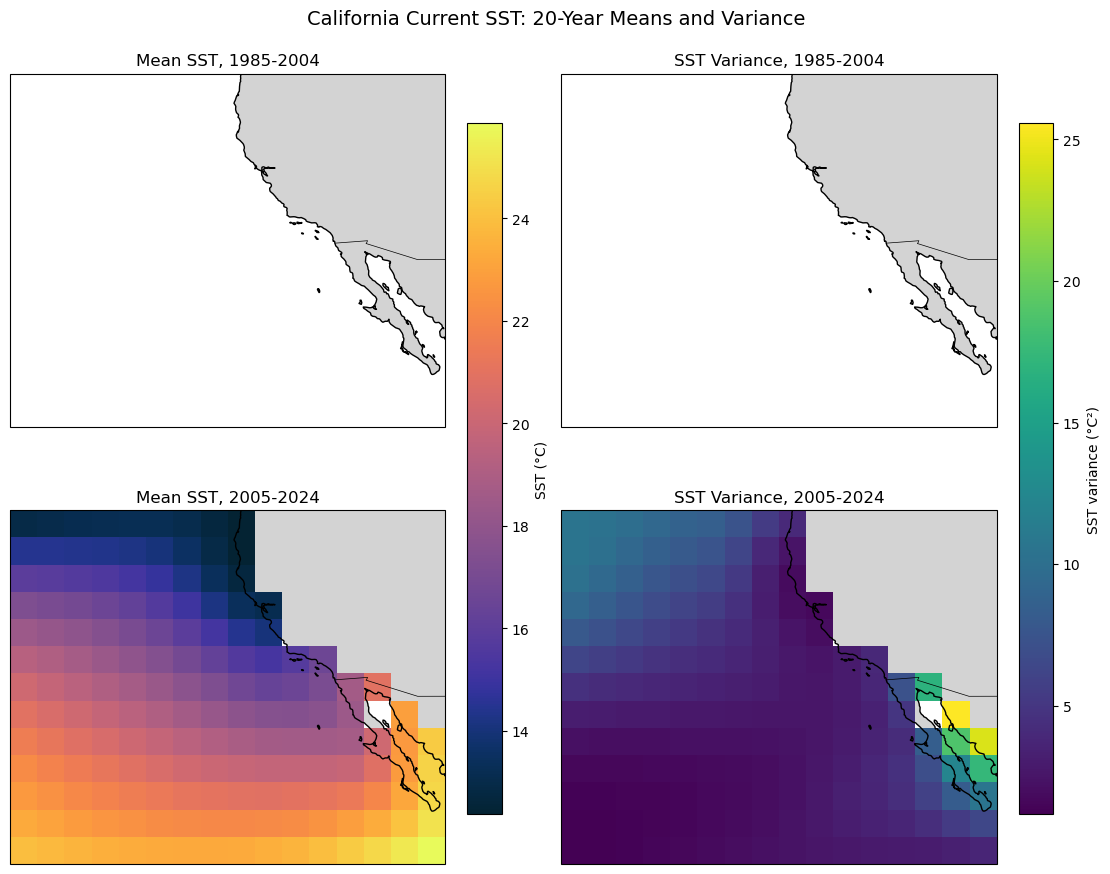

In [5]:
fig, axs = plt.subplots(
    2, 2, figsize=(11, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for row, ((label, start, end), pm, pv) in enumerate(zip(periods, period_means, period_vars)):
    ax_mean, ax_var = axs[row]

    im_mean = pm.plot.pcolormesh(
        ax=ax_mean, x="lon", y="lat",
        vmin=mean_vmin, vmax=mean_vmax,
        cmap=cm.thermal,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )
    im_var = pv.plot.pcolormesh(
        ax=ax_var, x="lon", y="lat",
        vmin=var_vmin, vmax=var_vmax,
        cmap="viridis",
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )

    for ax in (ax_mean, ax_var):
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax_mean.set_title(f"Mean SST, {label}")
    ax_var.set_title(f"SST Variance, {label}")

fig.colorbar(im_mean, ax=axs[:, 0], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_var, ax=axs[:, 1], orientation="vertical", shrink=0.8, label="SST variance (°C²)")
fig.suptitle("California Current SST: 20-Year Means and Variance", fontsize=14)
plt.show()

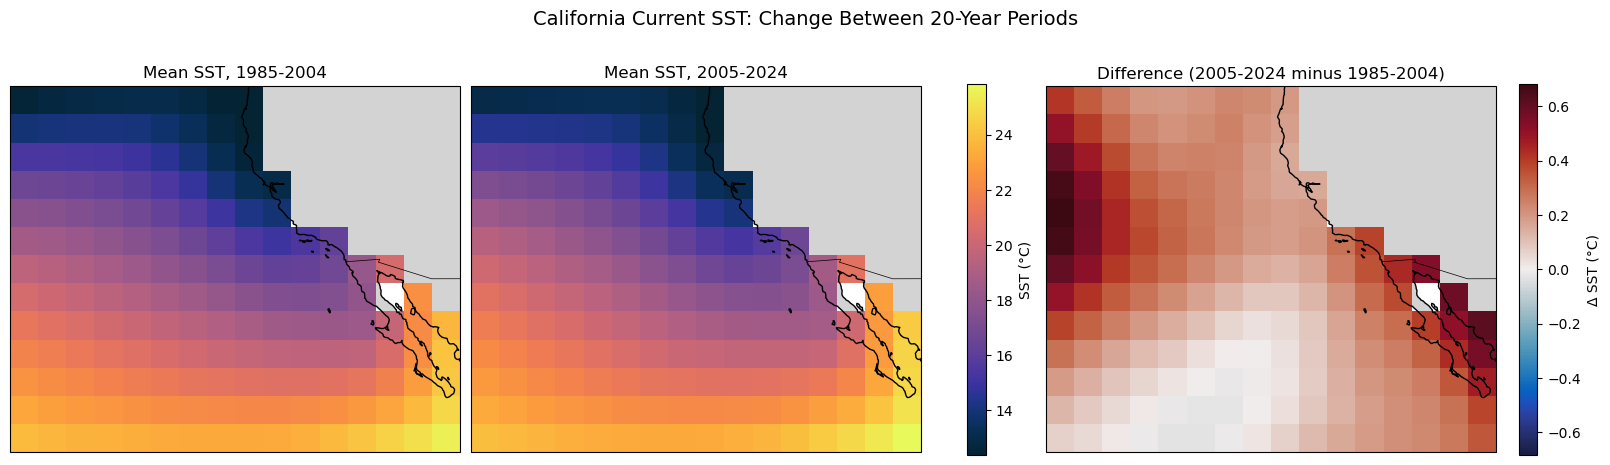

In [13]:
diff = period_means[1] - period_means[0]
diff_abs_max = np.abs(diff).max().item()

fig, axs = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_mean0 = period_means[0].plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[0].set_title(f"Mean SST, {periods[0][0]}")

im_mean1 = period_means[1].plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[1].set_title(f"Mean SST, {periods[1][0]}")

im_diff = diff.plot.pcolormesh(
    ax=axs[2], x="lon", y="lat",
    vmin=-diff_abs_max, vmax=diff_abs_max,
    cmap=cm.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[2].set_title(f"Difference ({periods[1][0]} minus {periods[0][0]})")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_mean1, ax=axs[:2], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_diff, ax=axs[2], orientation="vertical", shrink=0.8, label="Δ SST (°C)")
fig.suptitle("California Current SST: Change Between 20-Year Periods", fontsize=14)
plt.show()

### 1a) Linear Interpolation with Xarray



In [ ]:
sst_period0 = period_data[0]

# drop timesteps that are entirely missing, then interpolate back onto the full time axis
sst_valid = sst_period0.dropna(dim="time", how="all")
sst_filled = sst_valid.interp_like(sst_period0.time, method="linear")

print("NaNs in 2000 before interpolation:", int(sst_period0.sel(time="2000").isnull().sum()))
print("NaNs in 2000 after interpolation: ", int(sst_filled.sel(time="2000").isnull().sum()))

NaNs in 2000 before interpolation: 2496
NaNs in 2000 after interpolation:  492


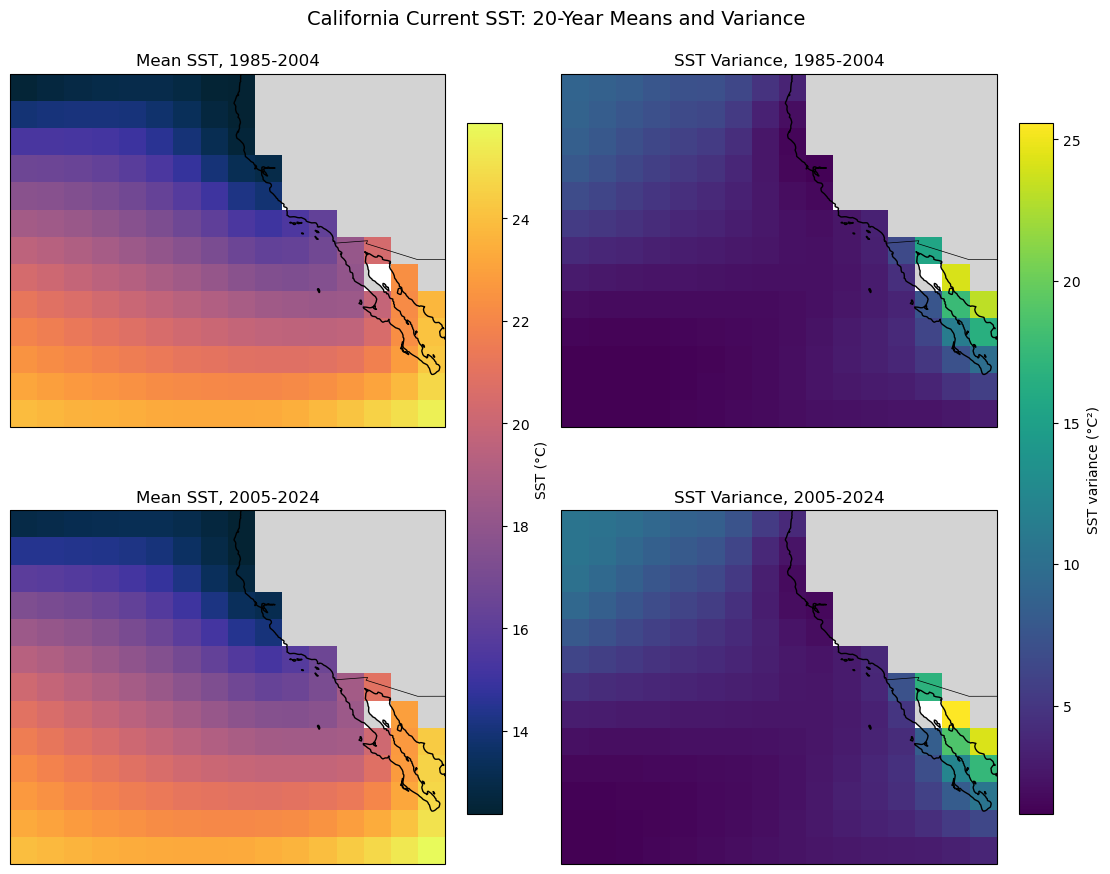

In [8]:
sst_filled_mean = sst_filled.mean(dim="time", skipna = False)
sst_filled_var = sst_filled.var(dim = "time", skipna = False)

period_means[0] = sst_filled_mean
period_vars[0] = sst_filled_var

fig, axs = plt.subplots(
    2, 2, figsize=(11, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for row, ((label, start, end), pm, pv) in enumerate(zip(periods, period_means, period_vars)):
    ax_mean, ax_var = axs[row]

    im_mean = pm.plot.pcolormesh(
        ax=ax_mean, x="lon", y="lat",
        vmin=mean_vmin, vmax=mean_vmax,
        cmap=cm.thermal,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )
    im_var = pv.plot.pcolormesh(
        ax=ax_var, x="lon", y="lat",
        vmin=var_vmin, vmax=var_vmax,
        cmap="viridis",
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )

    for ax in (ax_mean, ax_var):
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax_mean.set_title(f"Mean SST, {label}")
    ax_var.set_title(f"SST Variance, {label}")

fig.colorbar(im_mean, ax=axs[:, 0], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_var, ax=axs[:, 1], orientation="vertical", shrink=0.8, label="SST variance (°C²)")
fig.suptitle("California Current SST: 20-Year Means and Variance", fontsize=14)
plt.show()

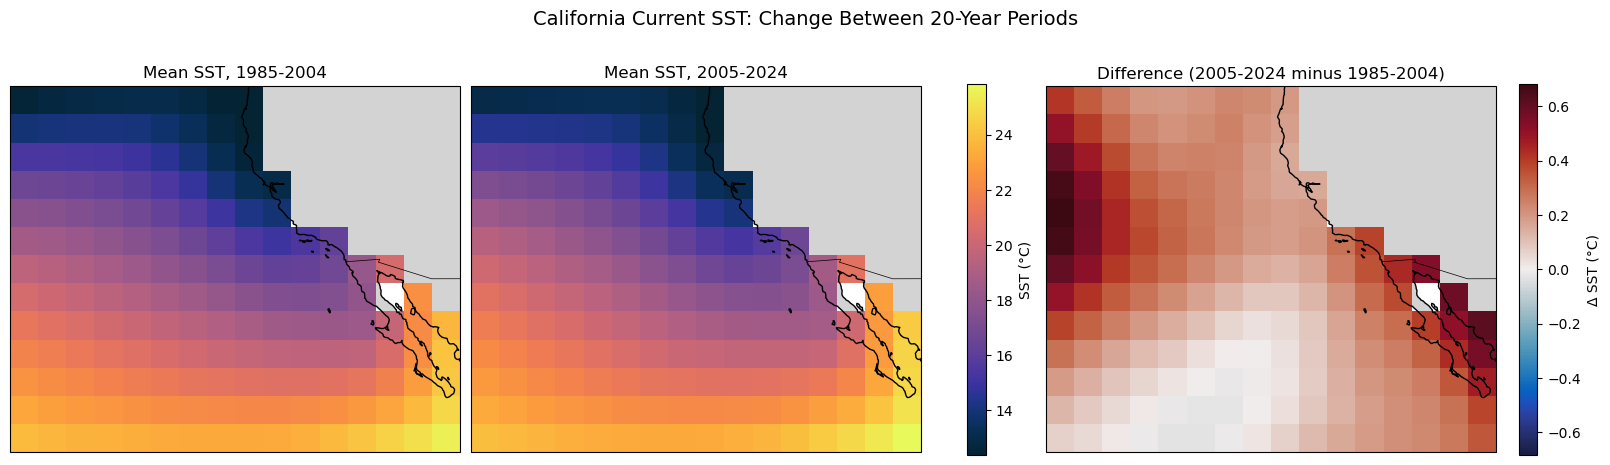

In [9]:
diff = period_means[1] - period_means[0]
diff_abs_max = np.abs(diff).max().item()

fig, axs = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_mean0 = period_means[0].plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[0].set_title(f"Mean SST, {periods[0][0]}")

im_mean1 = period_means[1].plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[1].set_title(f"Mean SST, {periods[1][0]}")

im_diff = diff.plot.pcolormesh(
    ax=axs[2], x="lon", y="lat",
    vmin=-diff_abs_max, vmax=diff_abs_max,
    cmap=cm.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[2].set_title(f"Difference ({periods[1][0]} minus {periods[0][0]})")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_mean1, ax=axs[:2], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_diff, ax=axs[2], orientation="vertical", shrink=0.8, label="Δ SST (°C)")
fig.suptitle("California Current SST: Change Between 20-Year Periods", fontsize=14)
plt.show()

## 1c) Your Turn

In [ ]:
# OISST climatology
oisst = xr.open_dataset("data/sst.oisst.mon.ltm.1991-2020.nc", decode_times=False)

# OISST lat runs south-to-north (ascending)
oisst_ccs_lat = slice(20, 45)
oisst_ccs = oisst.sst.sel(lon=ccs_lon, lat=oisst_ccs_lat)

# take mean over the entire time period
oisst_mean = oisst_ccs.mean(dim="time")

In [ ]:
# mean from the monthly-mean product over the same 1991-2020 period
sst_mean_1991_2020 = (
    xr.open_dataset("data/sst_monthlymean.nc")
    .sst.sel(lon=ccs_lon, lat=ccs_lat)
    .sel(time=slice("1991-01-01", "2020-12-31"))
    .mean(dim="time")
)

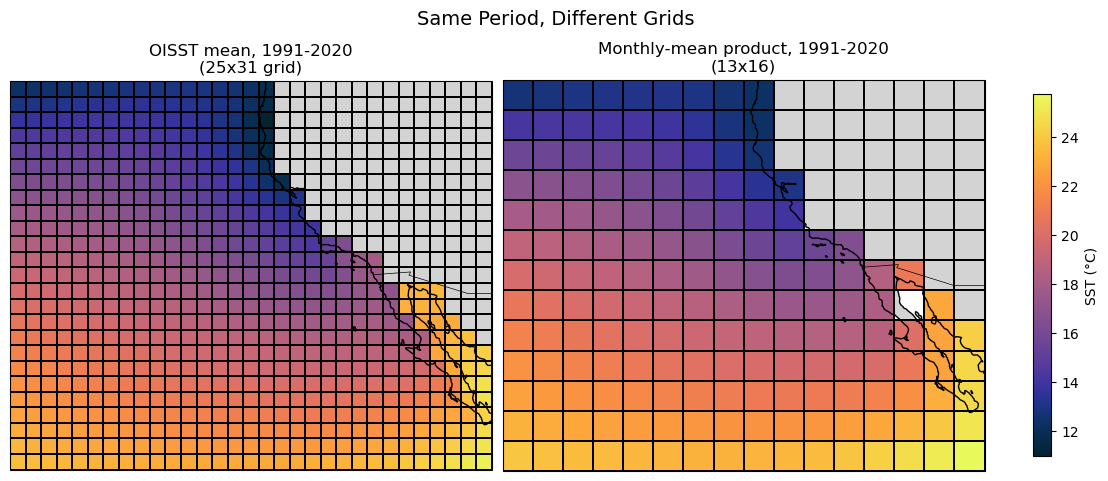

In [ ]:
native_vmin = min(oisst_mean.min().item(), sst_mean_1991_2020.min().item())
native_vmax = max(oisst_mean.max().item(), sst_mean_1991_2020.max().item())

fig, axs = plt.subplots(
    1, 2, figsize=(11, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_oisst_native = oisst_mean.plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=native_vmin, vmax=native_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    edgecolor="k", linewidth=0.05,
    add_colorbar=False,
)
axs[0].set_title(f"OISST mean, 1991-2020\n({oisst_mean.sizes['lat']}x{oisst_mean.sizes['lon']} grid)")

im_monthly_native = sst_mean_1991_2020.plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=native_vmin, vmax=native_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    edgecolor="k", linewidth=0.3,
    add_colorbar=False,
)
axs[1].set_title(f"Monthly-mean product, 1991-2020\n({sst_mean_1991_2020.sizes['lat']}x{sst_mean_1991_2020.sizes['lon']})")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_monthly_native, ax=axs, orientation="vertical", shrink=0.8, label="SST (°C)")
fig.suptitle("Same Period, Different Grids", fontsize=14)
plt.show()

### SOLUTION

In [ ]:
# interpolate the coarser 2deg product onto OISST's finer 0.25deg grid,
# so we can compare/difference the two products point-by-point
monthly_on_oisst_grid = sst_mean_1991_2020.interp_like(oisst_mean)

diff = oisst_mean - monthly_on_oisst_grid
diff.name = "sst"

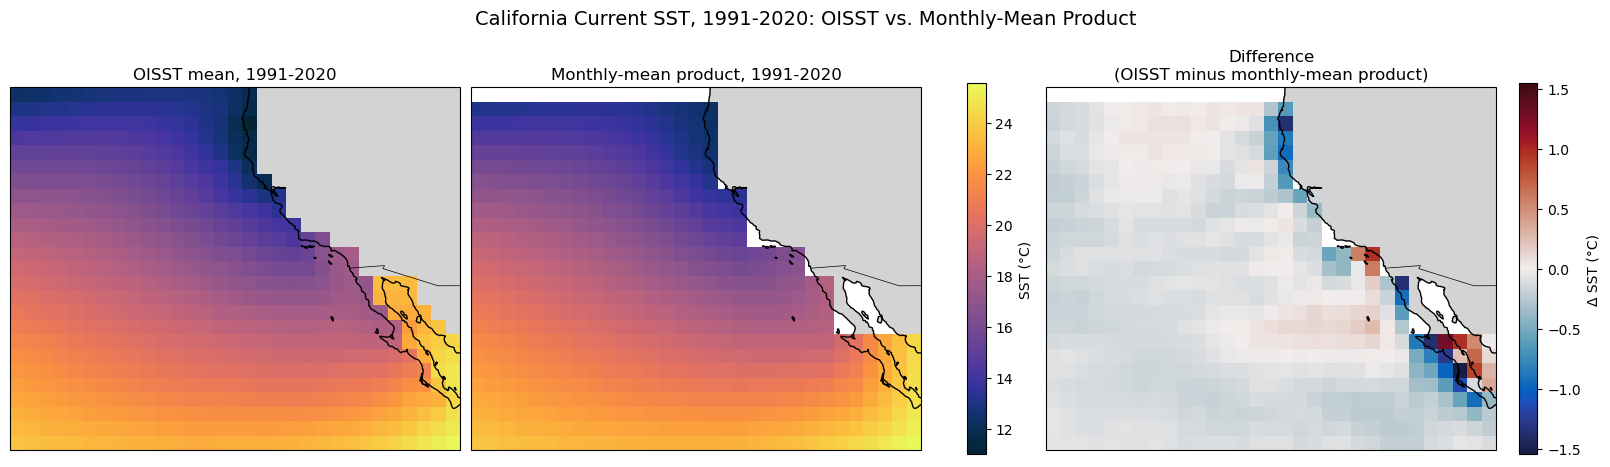

In [18]:
prod_vmin = min(oisst_mean.min().item(), monthly_on_oisst_grid.min().item())
prod_vmax = max(oisst_mean.max().item(), monthly_on_oisst_grid.max().item())
diff_abs_max = np.abs(diff).max().item()

fig, axs = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_oisst = oisst_mean.plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=prod_vmin, vmax=prod_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[0].set_title("OISST mean, 1991-2020")

im_monthly = monthly_on_oisst_grid.plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=prod_vmin, vmax=prod_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[1].set_title("Monthly-mean product, 1991-2020")

im_diff = diff.plot.pcolormesh(
    ax=axs[2], x="lon", y="lat",
    vmin=-diff_abs_max, vmax=diff_abs_max,
    cmap=cm.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[2].set_title("Difference\n(OISST minus monthly-mean product)")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_monthly, ax=axs[:2], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_diff, ax=axs[2], orientation="vertical", shrink=0.8, label="Δ SST (°C)")
fig.suptitle("California Current SST, 1991-2020: OISST vs. Monthly-Mean Product", fontsize=14)
plt.show()

## 2) Statistics with Scipy, Numpy, and Xarray
Teacher: Argen Smith
TA: Sophie Wynn, Tommy Stone



In [ ]:
# open tide data
tide_ds = xr.open_dataset('data/h554.nc').mean('record_id')

tide_ds

<xarray.Dataset> Size: 14MB
Dimensions:               (time: 894111)
Coordinates:
  * time                  (time) datetime64[ns] 7MB 1924-08-01T08:00:00 ... 2...
Data variables:
    sea_level             (time) float32 4MB 2.104e+03 1.677e+03 ... 2.171e+03
    quality               (time) float32 4MB 4.0 4.0 4.0 4.0 ... 3.0 3.0 3.0 3.0
    lat                   float64 8B 32.87
    lon                   float64 8B 242.7
    station_country_code  float64 8B 840.0
    uhslc_id              float64 8B 554.0
    gloss_id              float64 8B 159.0

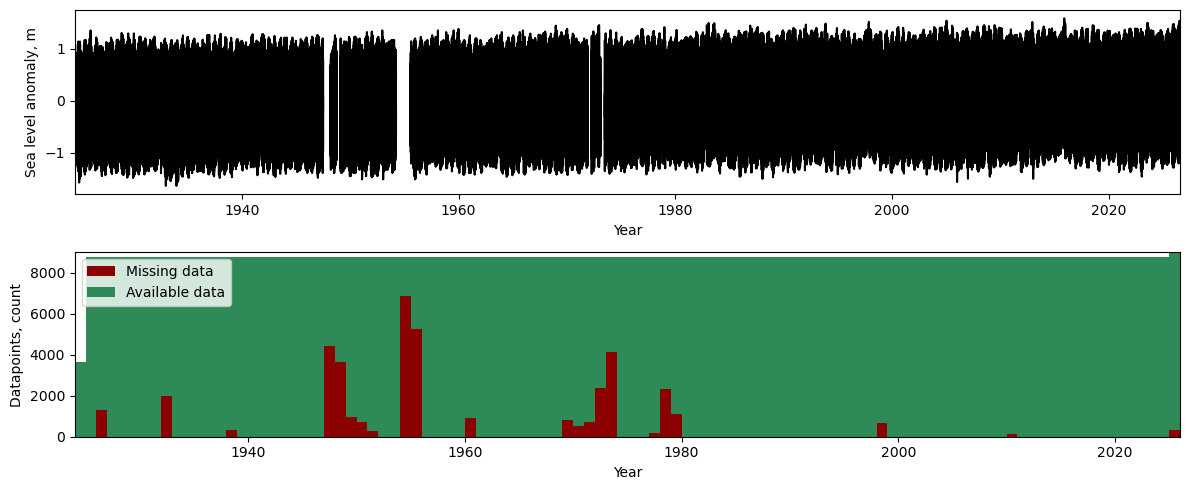

In [4]:
fig, axs = plt.subplots(2, figsize=(12, 5))

ax = axs[0]
sla = (tide_ds.sea_level - np.nanmean(tide_ds.sea_level.data))/1000 # remove mean and convert to meters!
sla.plot(ax=ax, x='time', color='black')
ax.set_ylabel('Sea level anomaly, m')
ax.set_xlabel('Year')
ax.set_xlim([np.datetime64('1924-08-01T08:00:00.000000000'), np.datetime64('2026-07-31T21:00:00.000000000')])

ax = axs[1]
# show how many missing data points we have per year. Calculate the years, pick out points with missing data
missing_data = np.zeros_like(sla.data)*np.nan
notmissing_data = missing_data.copy()
years = tide_ds.time.data.astype('datetime64[Y]').astype(int) + 1970
nanmask = np.isnan(sla.data)
missing_data[nanmask] = years[nanmask]
notmissing_data[~nanmask] = years[~nanmask]

missing_hist = np.histogram(missing_data, bins=np.arange(1924, 2027))
notmissing_hist = np.histogram(notmissing_data, bins=np.arange(1924, 2027))
ax.bar(np.arange(1924, 2026)+0.5, missing_hist[0], color='darkred', label='Missing data', width=1)
ax.bar(np.arange(1924, 2026)+0.5, notmissing_hist[0], color='seagreen', bottom=missing_hist[0], label='Available data', width=1)
ax.legend()

#ax.hist(missing_data, bins = np.arange(1924, 2026), color='firebrick')
ax.set_ylabel('Datapoints, count')
ax.set_xlabel('Year')
ax.set_xlim([1924, 2026])
ax.set_ylim([0, 9000])


fig.tight_layout()


### Histograms (for stats and utility)

The second plot there uses the first useful function from numpy/scipy/matplotlib, histogram. 

Let's make a simple histogram to pick out how these are useful. 

(array([1.0000e+01, 2.3000e+01, 7.1000e+01, 2.6300e+02, 7.0400e+02,
        1.3200e+03, 2.4130e+03, 3.4780e+03, 5.0920e+03, 7.9700e+03,
        9.3960e+03, 1.1719e+04, 1.3982e+04, 1.6635e+04, 1.8765e+04,
        1.9831e+04, 2.1835e+04, 2.3839e+04, 2.7876e+04, 2.7838e+04,
        3.0824e+04, 3.2950e+04, 3.6585e+04, 4.0153e+04, 4.1856e+04,
        4.3777e+04, 4.5462e+04, 4.9236e+04, 4.1188e+04, 3.8873e+04,
        3.5643e+04, 3.1803e+04, 2.9134e+04, 2.5173e+04, 2.3482e+04,
        2.1287e+04, 1.6916e+04, 1.4343e+04, 1.1749e+04, 9.2600e+03,
        7.4780e+03, 5.1450e+03, 3.5680e+03, 2.3820e+03, 1.4370e+03,
        7.6200e+02, 3.2600e+02, 1.0600e+02, 3.4000e+01, 3.0000e+00]),
 array([-1.63416278, -1.56972277, -1.50528276, -1.44084275, -1.37640274,
        -1.31196284, -1.24752283, -1.18308282, -1.11864281, -1.0542028 ,
        -0.98976278, -0.92532283, -0.86088282, -0.79644281, -0.73200279,
        -0.66756284, -0.60312283, -0.53868282, -0.47424284, -0.40980282,
        -0.34536284, -0.28

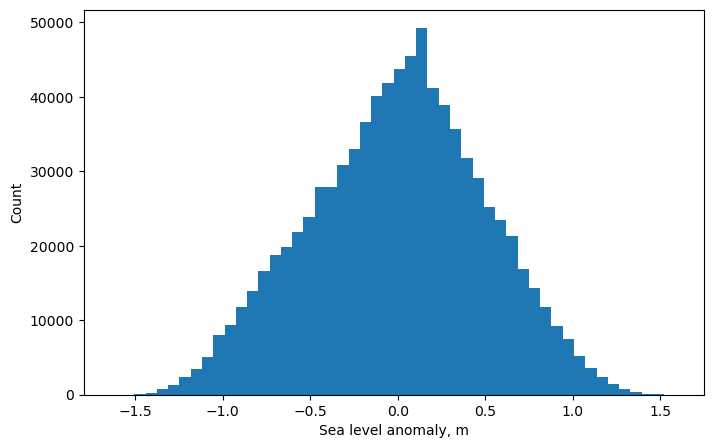

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

a = ax.hist(sla, bins=50)
ax.set_ylabel('Count')
ax.set_xlabel('Sea level anomaly, m')

a

Looking at the plot:
- There is a peak at 0! (We subtracted out the mean, so this makes sense)
- Wide peak/not exactly gaussian (the signal is not stationary, sea level rise)

And looking at the output of the histogram function from [matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html):
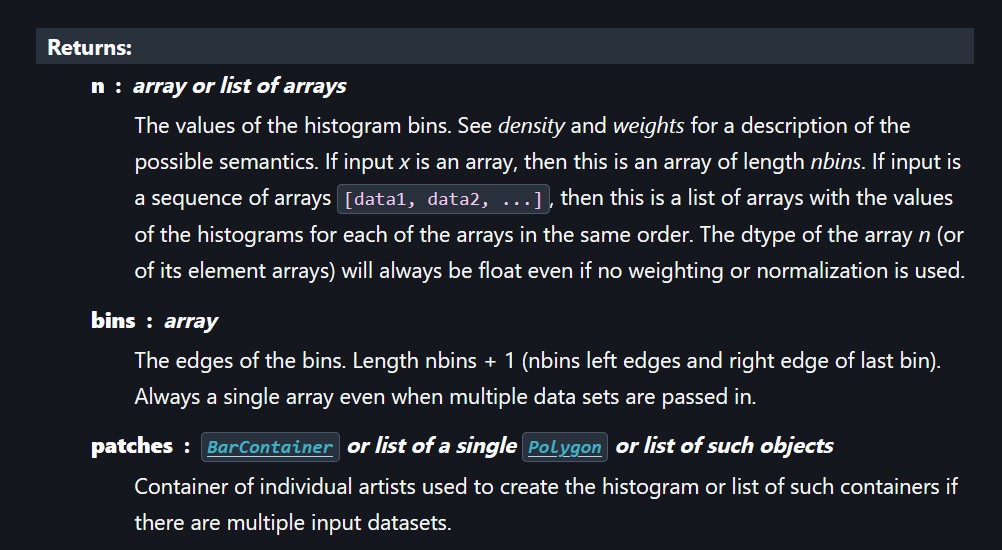

we get the bins and histogram values for our dataset. Note that the list of bins is one longer than the list of values.

### Other basics: Exercise!

Numpy and scipy are mostly useful for implementing the basic stats functions you'll use over and over. They're very clearly documented and easy to use, so we'll do this as an exercise to check that everyone has been able to download the data and use their installed modules. 

1. Make arrays that include the tidal data for only the first year and only the last year, take the mean of each of these. 
2. Find the variance, skew, and kurtosis of each. Are they guassian? (Hint: the gaussian is defined as the distribution with nonzero mean and variance, but zero for all higher moments including skew and kurtosis)
3. Plot the histogram of these years, does this seem to agree with the stats you've calculated?


Extention: Can you show if this change in sea level height is statistically significant?

first year mean: <xarray.DataArray 'sea_level' ()> Size: 8B
array(-0.13671835)


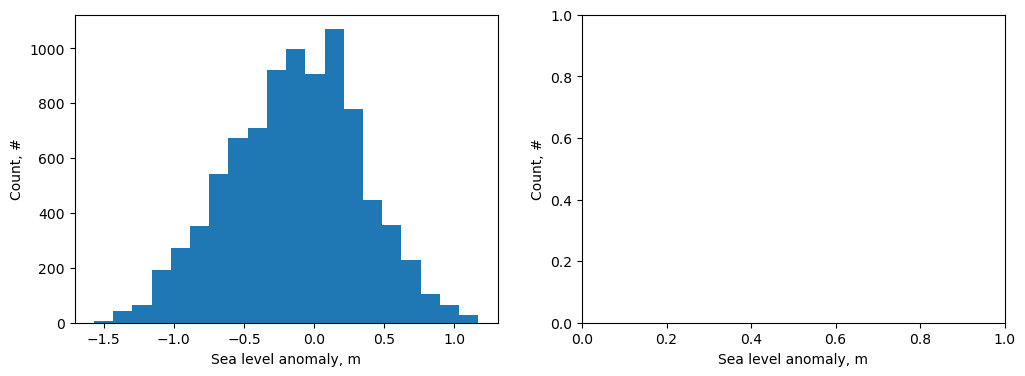

In [27]:
# some scaffolding of a solution. If you're confident, try starting yourself first! 
firstend_date = np.min(tide_ds.time.data) + np.timedelta64(1, 'Y').astype('<m8[ns]')
#lastend_date = 
firstyears = sla.where(tide_ds.time < firstend_date, drop=True)
#lastyears = 

# calculate the means
first_mean = firstyears.mean()
#last_mean = 
print(f'first year mean: {first_mean}')

# calculate the variance, skew, kurtosis


# Plot the histograms
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(firstyears, bins=20)


for ax in axs:
    ax.set_xlabel('Sea level anomaly, m')
    ax.set_ylabel('Count, #')

### Power spectral density
The more visually obvious attribute of the tide data is that it varies quickly! You may have guessed that this is due to the tides. 

To look at tidal constituents, we'll plot a power spectral density (PSD), similar to a fourier transform, to look at the tidal constituents. The [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html ) has some more info on how this is computed. This is the Welch method, originally [published](10.1109/TAU.1967.1161901) in 1967. You'll learn a lot more about this method in the PO data 1 class. 

Fourier transforms don't work when there is missing data, so we will start by filtering for data since 1980 and interpolating to fill missing values. Here we'll use linear interpolation, which is far from the best way, but suitable for an example.

C:\Users\clair\AppData\Local\Temp\ipykernel_24904\1541953640.py:4: RuntimeWarning: divide by zero encountered in divide
  periods = 1/sla_psd[0]


Text(0.5, 1.0, 'Cropped around main tidal constituents')

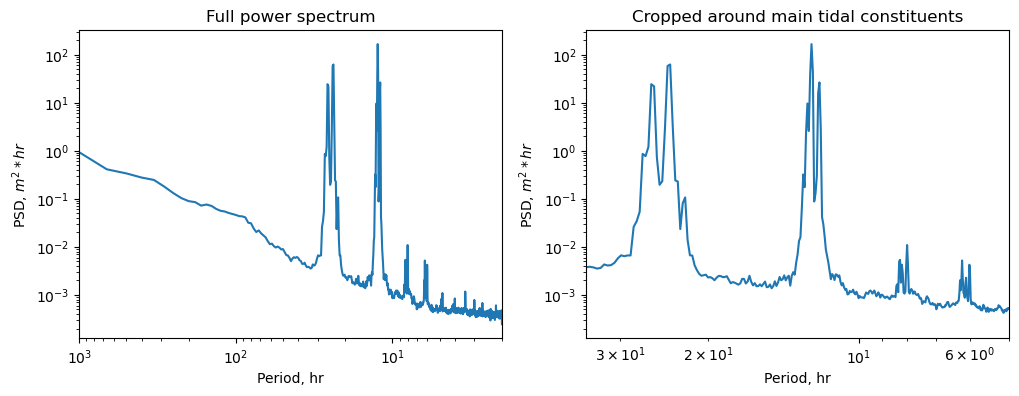

In [30]:
sla_clean = sla.interpolate_na(dim='time', method='linear') # bad practice

sla_psd = scipy.signal.welch(sla_clean.data[years>1980], detrend='linear', nperseg=2000)
periods = 1/sla_psd[0]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax in axs:
    ax.loglog(periods, sla_psd[1])
    ax.invert_xaxis()
    ax.set_xlabel('Period, hr')
    ax.set_ylabel('PSD, $m^2 * hr$')

ax = axs[0]
ax.set_xlim([1000, 2])
ax.set_title('Full power spectrum')

ax = axs[1]
ax.set_xlim([35, 5])
ax.set_title('Cropped around main tidal constituents')



#### practice:
There are more parameters than we have time to talk about that go into this PSD. For now we'll look at window size. Use the documentation for the PSD to figure out which parameter you should change in the function to vary the window size. Increase and decrease this drastically, how does the output change? Why might we want to use a higher or lower window size?

## 3) Machine Learning with SKlearn 
Teacher: Sophie Wynn
TAs: Argen Smith, Tommy Stone


## `sklearn`:

[scikit-learn](https://scikit-learn.org/stable/) (`sklearn`) is Python's standard machine learning
library, this package has tools for regression, classification, clustering, etc. The [User Guide](https://scikit-learn.org/stable/user_guide.html) is the best place to
look something up. 

**Machine Learning, (in short):** instead of fitting a formula relating your inputs
to your output. A model is shown input/output pairs and it *learns* the relationship. This learning is done through a variety of different methods, some in which models get there names by include, decision trees, random forests, guassian proccess regressors, neural networks etc. The user then checks whether the model has learned the relationship with held out test data. 

**Decision Trees** "are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation." Via [scikit-learn](https://scikit-learn.org/stable/modules/tree.html) 


**Random Forest:** a group ("ensemble") of decision trees, each trained on a
different random subset of the data and features, whose predictions get averaged together. A
single decision tree overfits easily; averaging many different, imperfect trees cancels most of
that out. 


**Feature importance:** Random Forests are useful when if you have multiple inputs and are trying to learn which features are most important to the model. For each split a tree picks the feature (and threshold) that reduces
prediction error the most; summing that error-reduction across every tree, per feature. A
higher feature importance means the model relied on that feature more to make its predictions.

**If you are interested in learning more about ML check out SIOC 209 Special Topics - Deep Learning in Earth Science, this spring**

A very similar package I use is [ESEm](https://esem.readthedocs.io/en/latest/index.html) which also uses sklearn but is more simple  streamlined made for emulate earth system datasets

![Decision tree diagram](https://blog.mindmanager.com/wp-content/uploads/2022/03/Decision-Tree-Diagram-Example-MindManager-Blog.png)

### Task: Use a random forest regressor to learn which variables are helpful for predicting chlorophyll, using the scripps pier dataset

In [4]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
np.random.seed(0)
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Scripps Pier shore station, 2005 

pier = xr.open_dataset("/Users/sophiewynn/Desktop/lesson plans/MathWorkShop/scripps_pier-2005.nc")

# using what we learned in the part 1 of the workship, convert to df. it is easier to work with a pandas dataframe for this part of the analysis
pier_df = pier[["temperature", "salinity", "pressure", "sigmat", "chlorophyll",
                "temperature_flagPrimary", "salinity_flagPrimary",
                "pressure_flagPrimary", "chlorophyll_flagPrimary"]].to_dataframe().reset_index()

# keep only QC-passed data (flag == 1 means "good data") -- real instrument data always needs this check
good = pier_df[
    (pier_df["temperature_flagPrimary"] == 1) & (pier_df["salinity_flagPrimary"] == 1) &
    (pier_df["pressure_flagPrimary"] == 1) & (pier_df["chlorophyll_flagPrimary"] == 1)
].dropna(subset=["temperature", "salinity", "pressure", "sigmat", "chlorophyll"])

features = ["temperature", "salinity", "pressure", "sigmat"] # these are the inputs 
target = "chlorophyll" # this is the output
sample = good.sample(15000, random_state=0)  # subsample for computational speed , this samples 15k rows from the good data for training/testing
sample.shape

(15000, 13)

In [5]:
# split up your inputs from your target variable


X, y = sample[features], sample[target]

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

# fit the model, note all of the hyperparameters can be tuned, but this is a good starting point
chloro_model = RandomForestRegressor(n_estimators=200, random_state=0)
chloro_model.fit(X_train, y_train) # make sure to train! 


#make predictions on the test set
y_pred = chloro_model.predict(X_test)




R² on held-out samples: 0.51


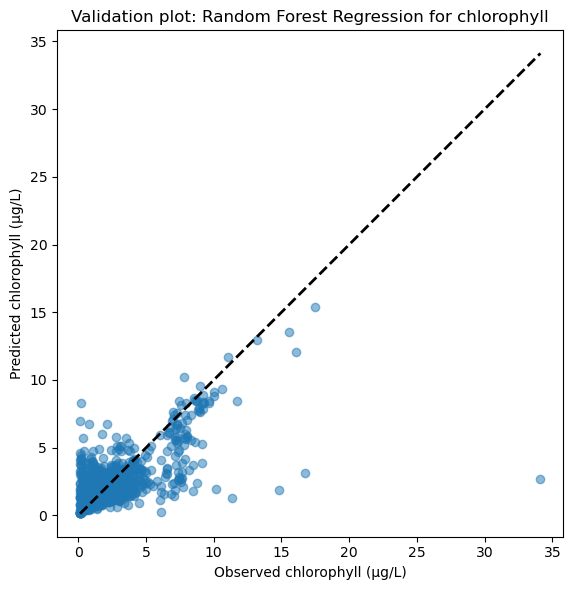

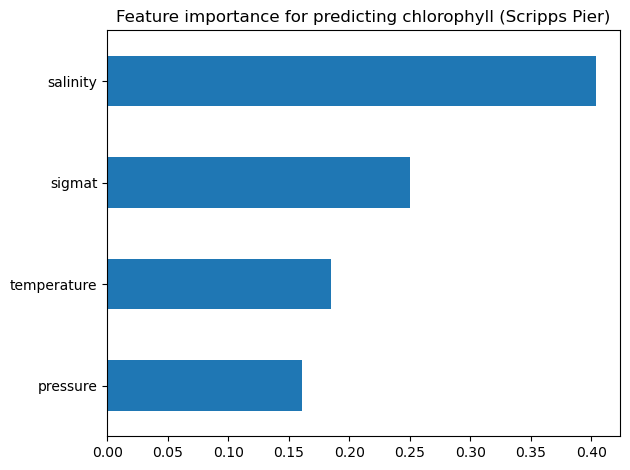

In [6]:

# R2 is calculated by taking the proportion of variance in the target variable that is explained by the model.
r2 = chloro_model.score(X_test, y_test)
print(f"R² on held-out samples: {r2:.2f}")

#plot a validation plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.5)
#make the axes equal so that the 1:1 line is at a 45 degree angle
ax.set_aspect('equal', adjustable='box')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax.set_xlabel("Observed chlorophyll (µg/L)")
ax.set_ylabel("Predicted chlorophyll (µg/L)")
ax.set_title("Validation plot: Random Forest Regression for chlorophyll")
plt.tight_layout()
plt.show()


#plot the feature importances
# pd.series allows you to create a series from an array and assign an index to it, which is useful for labeling the feature importances. 
# The `sort_values()` method sorts the feature importances in ascending order, and `plot.barh()` creates a horizontal bar plot of the sorted feature importances.
pd.Series(chloro_model.feature_importances_, index=features).sort_values().plot.barh(
    title="Feature importance for predicting chlorophyll (Scripps Pier)"
)
plt.tight_layout()
plt.show()

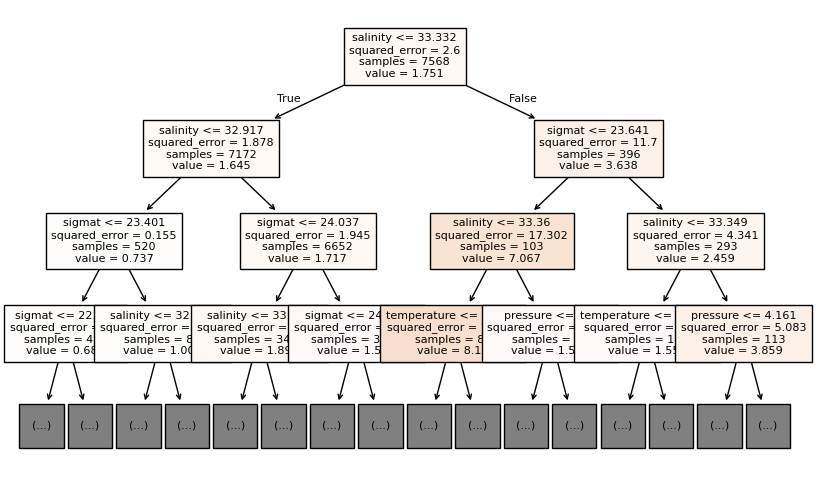

In [7]:
# you can also view the trees in the random forest model, but this is more for curiosity than for practical use.
from sklearn.tree import plot_tree

estimator = chloro_model.estimators_[0]  # get the first tree from the random forest

plt.figure(figsize=(10, 6))

plot_tree(
    estimator,
    feature_names=features,
    max_depth=3, #only display the first 3 levels of the tree
    filled=True, #colors the nodes based on the predicted value
    fontsize=8
)
plt.show()


### Practice problem: can you use a random forest to learn a time series and or a different non-linear relationship?

Using the sst data, build a random forest that predicts `temperature` using time as input. If it works, plotting the model's predictions across every day of the year should trace out a seasonal-like curve. You are also welcome to choose a different time series from a different dataset etc. 

Note: The Scripps Pier file only covers mid-June through December 2005 (day 167–365), so you'll only see cooling
into winter, not a full annual cycle. 


R² on held-out samples: 0.89


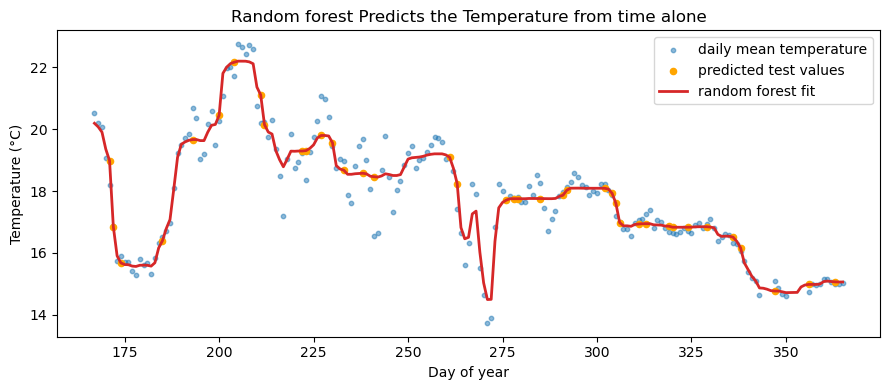

In [8]:
#1. SET UP your dataset

## add day of year column to the dataframe, from the scripps sst data
good["doy"] = good["time"].apply(lambda t: t.timetuple().tm_yday)
# average away the within-day and day-to-day noise
daily = good.groupby("doy", as_index=False)["temperature"].mean()


X, y = daily[["doy"]], daily["temperature"] # set the inputs and outputs 

#split up the test train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# this defines the model, which is a random forest regressor with 200 trees and a maximum depth of 5. The random_state ensures reproducibility, and n_jobs=-1 allows the model to use all available CPU cores for training.
sst_model = RandomForestRegressor(n_estimators=200, max_depth=5,
                              random_state=0, n_jobs=-1)

#fit the model
sst_model.fit(X_train, y_train)

#get the R² score on the held-out test set,
r2 = sst_model.score(X_test, y_test)
print(f"R² on held-out samples: {r2:.2f}")

# predict from the test inputs
y_pred = sst_model.predict(X_test)


#what shape did it actually learn? predict across every day it saw, plot as a curve
doy_grid = pd.DataFrame({"doy": np.arange(daily["doy"].min(), daily["doy"].max() + 1)})
predicted_cycle = sst_model.predict(doy_grid) # this predicits all of the days in the range of the training data, which is useful for visualizing the learned seasonal cycle.

plt.figure(figsize=(9, 4))
plt.scatter(daily["doy"], daily["temperature"], s=10, alpha=0.5, label="daily mean temperature")
# scatter in a different color the predicted test values
plt.scatter(X_test["doy"], y_pred, s=20, alpha=1.0, color="orange", label="predicted test values")
plt.plot(doy_grid["doy"], predicted_cycle, color="tab:red", lw=2, label="random forest fit")
plt.xlabel("Day of year")
plt.ylabel("Temperature (°C)")
plt.title("Random forest Predicts the Temperature from time alone")
plt.legend()
plt.tight_layout()
plt.show()

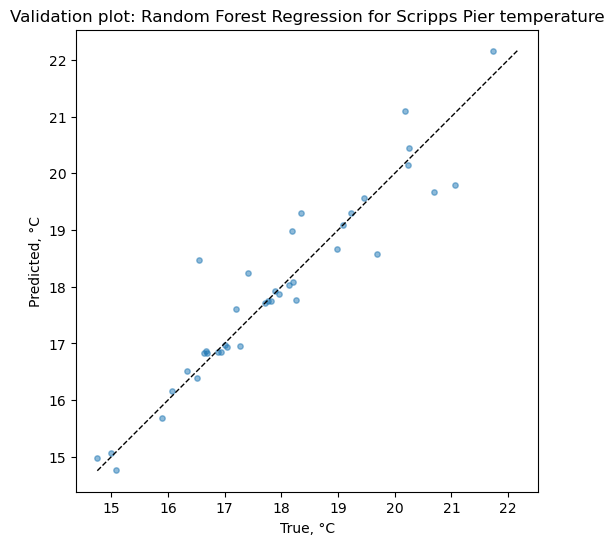

In [9]:
## predicted vs. actual plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.5, s=15)

# 1:1 line — perfect predictions would fall on this
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1)

ax.set_xlabel("True, °C")
ax.set_ylabel("Predicted, °C")
ax.set_title("Validation plot: Random Forest Regression for Scripps Pier temperature")
ax.set_aspect('equal')
plt.show()

# Questions:
1. If I gave the model, a time period outside of the training data, would it be able to predict the temperature? Why or why not?

2. Is there a better way to model the seasonal cycle than using a random forest? What would you suggest?

3. How could you improve the model's performance by incorporating additional features or data?

4. Is there any other models given all of the datsets provided that you would be interested in making?

Feel free to discuss these questions with your peers or ask the us for guidance.



In [ ]:
#aside
# ask the same fitted model for EVERY day of the year, including day 1-166 for the scripps pier data
#full_year_grid = pd.DataFrame({"doy": np.arange(1, 367)})
#full_year_prediction = sst_model.predict(full_year_grid)

#plt.figure(figsize=(9, 4))
#plt.scatter(daily["doy"], daily["temperature"], s=10, alpha=0.5, label="observed (training range)")
#plt.plot(full_year_grid["doy"], full_year_prediction, color="tab:red", lw=2, label="random forest prediction")
#plt.axvspan(1, daily["doy"].min(), color="gray", alpha=0.15, label="never seen in training")
#plt.xlabel("Day of year")
#plt.ylabel("Temperature (°C)")
#plt.title("Outside its training range, the random forest just flatlines")
#plt.legend()
#plt.tight_layout()
#plt.show()
